In [1]:
import numpy as np
import ase
import ase.io
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from itertools import product
from numpy import linalg as la

In [9]:
frames = ase.io.read("xyz_files/ellipsoids_with_axes.xyz", ":")
nframes = []
for frame in frames:
    if len(frame) == 1:
        nframes.append(frame * (2, 1, 1))
    elif len(frame) == 2:
        nframes.append(frame)
    else:
        assert 1 == 0, f"length is {len(frame)}"
frames = nframes

In [10]:
n = 2
pos_mats = []
or_mats = []
X = []
for frame in frames:
    positions = []
    orientations = []
    x0 = []
    triples = product(range(0, n), repeat=3)
    a, b, c = frame.get_cell()
    translation_vecs = [t[0]*a + t[1]*b + t[2]*c for t in triples]
    assert len(translation_vecs) == n**3, f"num translation vectors is {len(translation_vecs)}"
    for vec in translation_vecs:
        positions.append(np.array(frame.positions[0]) + np.array(vec))
        orientations.append(frame.arrays["or_vec"][0])
        x0.append([positions[-1], orientations[-1]])
        positions.append(np.array(frame.positions[1]) + np.array(vec))
        orientations.append(frame.arrays["or_vec"][1])
        x0.append([positions[-1], orientations[-1]])
    assert np.shape(positions) == np.shape(orientations) == (2 * n**3, 3)  # shape (num_atoms, num_dimensions)
    pos_mats.append(positions)
    or_mats.append(orientations)
    X.append(x0)

assert np.shape(pos_mats) == np.shape(or_mats) and np.shape(or_mats) == (len(frames), 2 * n**3, 3)
X = np.array(X)
print("frames, atoms, pos/or, vecs")
print(np.shape(X))

frames, atoms, pos/or, vecs
(6826, 16, 2, 3)


In [11]:
idx_i, idx_j = np.triu_indices(2 * n**3, k=1)

pos_i = X[:, idx_i, 0, :]
pos_j = X[:, idx_j, 0, :]

r = pos_j - pos_i
print(np.shape(r))

uhat1 = X[:, idx_i, 1, :]
uhat2 = X[:, idx_j, 1, :]
print(np.shape(uhat1))
print(np.shape(uhat2))

new_X = np.stack((uhat1, uhat2, r), axis=-2)
testX = np.stack((uhat1, uhat2, r, np.zeros_like(r)), axis=-2)
print(np.shape(new_X))
print(np.shape(testX))

(6826, 120, 3)
(6826, 120, 3)
(6826, 120, 3)
(6826, 120, 3, 3)
(6826, 120, 4, 3)


In [13]:
def gb_shape_function(uhat1, uhat2, rhat, sigma0, kappa):
    chi = (kappa**2 - 1)/(kappa**2 + 1)
    term1 = (np.vecdot(uhat1, rhat) + np.vecdot(uhat2, rhat))**2 / (1 + chi*np.vecdot(uhat1, uhat2))
    term2 = (np.vecdot(uhat1, rhat) - np.vecdot(uhat2, rhat))**2 / (1 - chi*np.vecdot(uhat1, uhat2))
    sigma = sigma0 / np.sqrt(1 - (chi / 2)*(term1 + term2))
    return sigma


def gb_axial_energy(uhat1, uhat2, kappa):
    chi = (kappa**2 - 1)/(kappa**2 + 1)
    return 1 / np.sqrt(1 - (chi*np.vecdot(uhat1, uhat2))**2)


def gb_directional_energy(uhat1, uhat2, rhat, kappa_prime, mu):
    chi_prime = (kappa_prime**(1/mu) - 1) / (kappa_prime**(1/mu) + 1)
    term1 = (np.vecdot(uhat1, rhat) + np.vecdot(uhat2, rhat))**2 / (1 + chi_prime*np.vecdot(uhat1, uhat2))
    term2 = (np.vecdot(uhat1, rhat) - np.vecdot(uhat2, rhat))**2 / (1 - chi_prime*np.vecdot(uhat1, uhat2))
    return 1 - chi_prime*(term1 + term2) / 2


def gb_energy_function(uhat1, uhat2, rhat, eps0, kappa, kappa_prime, mu, nu):
    eps1 = gb_axial_energy(uhat1, uhat2, kappa)
    eps2 = gb_directional_energy(uhat1, uhat2, rhat, kappa_prime, mu)
    return eps0 * eps1**nu * eps2**mu


def gb(uhat1, uhat2, r, sigma0, eps0, kappa, kappa_prime, mu, nu):
    rmag = np.expand_dims(la.norm(r, axis=-1), axis=-1)
    rhat = r / rmag
    eps = gb_energy_function(uhat1, uhat2, rhat, eps0, kappa, kappa_prime, mu, nu)
    sigma = gb_shape_function(uhat1, uhat2, rhat, sigma0, kappa)
    term = sigma0 / (la.norm(r, axis=-1) - sigma + sigma0)
    res = 4 * eps * (term**12 - term**6)
    return res


def quadrupole(uhat1, uhat2, r, Q):
    rmag = np.expand_dims(la.norm(r, axis=-1), axis=-1)
    rhat = r / rmag
    a1 = np.vecdot(uhat1, rhat)
    a2 = np.vecdot(uhat2, rhat)
    b12 = np.vecdot(uhat1, uhat2)
    prefactor = 0.75 * Q**2 / rmag**5
    s = 1 + 2*b12**2 - 5*(a1**2 + a2**2) - 20*a1*a2*b12 + 35*(a1**2)*(a2**2)
    prefactor = np.squeeze(prefactor)
    return prefactor * s


def get_total_energy(M, sigma0, eps0, kappa, kappa_prime, mu, nu, Q):
    # M should have shape (N, 1431, 3, 3) where N is the number of frames
    E_GB = gb(M[:, :, 0, :], M[:, :, 1, :], M[:, :, 2, :], sigma0, eps0, kappa, kappa_prime, mu, nu)
    E_QQ = quadrupole(M[:, :, 0, :], M[:, :, 1, :], M[:, :, 2, :], Q)
    E_QQ = np.squeeze(E_QQ)
    pw_energies = E_GB + E_QQ
    # pw_energies should have shape (N, 1431)
    energies = np.sum(pw_energies, axis=-1)
    return energies


def get_molecular_energy(M, sigma0, eps0, kappa, kappa_prime, mu, nu, Q):
    energies = get_total_energy(M, sigma0, eps0, kappa, kappa_prime, mu, nu, Q)
    return energies / (2 * n**3)

In [23]:
Y = [frame.info["intermolecular_energy_pa"] * 12 for frame in frames]

#              sigma0, eps0, kappa, kappa_prime, mu, nu, Q
p0 =           [6.2, 0.0347, 0.542, 3.000, -10.0, 1.000, -3.263]
lower_bounds = [4.6, 0.0200, 0.100, 0.001, -15.0, -15.0, -12]
upper_bounds = [6.9, 0.0800, 0.800, 5.000, 10.00, 10.00, -2]
bounds = (lower_bounds, upper_bounds)

def gb_wrapper(matrix, sigma0, eps0, kappa, kappa_prime, mu, nu, Q):
    return get_molecular_energy(matrix, sigma0, eps0, kappa, kappa_prime, mu, nu, Q)

In [32]:
results1 = curve_fit(
    gb_wrapper,
    new_X,
    Y,
    p0=p0,
    bounds=bounds,
    maxfev=10_000,
    loss="soft_l1",
    f_scale=0.2
)

print(results1)

(array([ 6.16753952,  0.08      ,  0.53134663,  0.68032599, -0.39313992,
        4.37606907, -3.83795985]), array([[ 8.62933172e-05, -1.36514012e-05, -1.30071276e-05,
        -2.17577819e-04, -1.72176206e-03, -2.35834708e-04,
         1.99580187e-04],
       [-1.36514012e-05,  1.00784051e-05,  1.88367551e-06,
         7.22502427e-05,  3.71068660e-05, -5.01446998e-04,
        -2.14415652e-04],
       [-1.30071276e-05,  1.88367551e-06,  2.41202095e-06,
         3.47585448e-05,  2.93932818e-04,  5.41364865e-05,
        -1.87601473e-05],
       [-2.17577819e-04,  7.22502427e-05,  3.47585448e-05,
         1.13422715e-03,  2.30463036e-03, -1.71132738e-03,
        -2.83347857e-03],
       [-1.72176206e-03,  3.71068660e-05,  2.93932818e-04,
         2.30463036e-03,  7.22995283e-02,  2.68882435e-02,
         8.72679887e-03],
       [-2.35834708e-04, -5.01446998e-04,  5.41364865e-05,
        -1.71132738e-03,  2.68882435e-02,  4.00742578e-02,
         1.20891519e-02],
       [ 1.99580187e-04, -2.

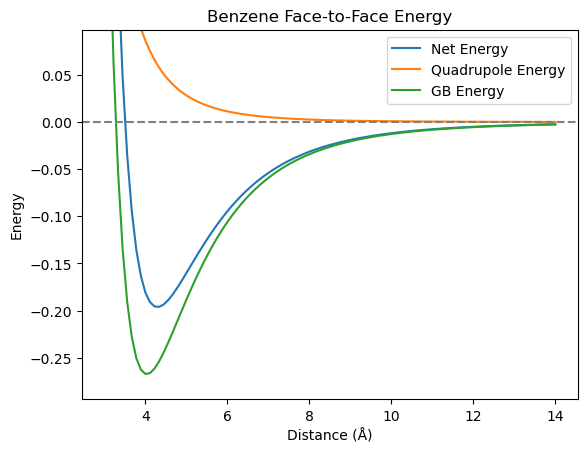

In [49]:
popt = results1[0]

# face-to-face energy curve
u1 = np.array([0, 0, 1])
u2 = np.array([0, 0, 1])

distances = np.linspace(3.0, 14.0, 100)
gb_face_energies = []
qq_face_energies = []
face_energies = []

for d in distances:
    r = np.array([0, 0, d])
    gb_e = gb(u1, u2, r, popt[0], popt[1], popt[2], popt[3], popt[4], popt[5])
    qq_e = quadrupole(u1, u2, r, popt[6])
    gb_face_energies.append(gb_e)
    qq_face_energies.append(qq_e)
    face_energies.append(gb_e + qq_e)

# plot Face-to-Face energy
plt.plot(distances, face_energies, label='Net Energy')
plt.plot(distances, qq_face_energies, label='Quadrupole Energy')
plt.plot(distances, gb_face_energies, label='GB Energy')
plt.axhline(0, color='gray', linestyle='--')
plt.ylim(min(face_energies)*1.5, abs(min(face_energies))*0.5)
plt.xlabel('Distance (Å)')
plt.ylabel('Energy')
plt.title(f'Benzene Face-to-Face Energy')
plt.legend()
plt.show()

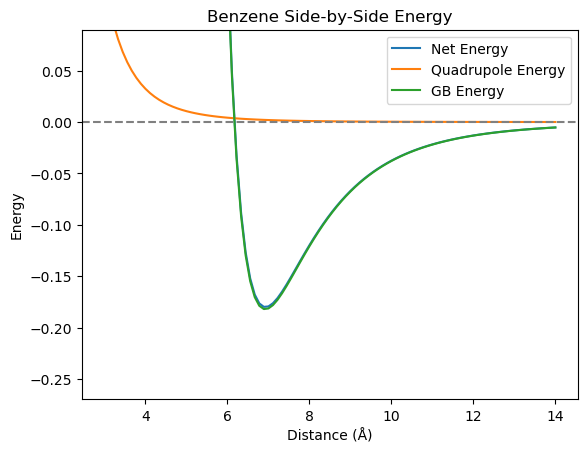

In [50]:
gb_edge_energies = []
qq_edge_energies = []
edge_energies = []

for d in distances:
    r = np.array([d, 0, 0])
    gb_e = gb(u1, u2, r, popt[0], popt[1], popt[2], popt[3], popt[4], popt[5])
    qq_e = quadrupole(u1, u2, r, popt[6])
    gb_edge_energies.append(gb_e)
    qq_edge_energies.append(qq_e)
    edge_energies.append(gb_e + qq_e)

# plot Edge-to-Edge energy
plt.plot(distances, edge_energies, label='Net Energy')
plt.plot(distances, qq_edge_energies, label='Quadrupole Energy')
plt.plot(distances, gb_edge_energies, label='GB Energy')
plt.axhline(0, color='gray', linestyle='--')
plt.ylim(min(edge_energies)*1.5, abs(min(edge_energies))*0.5)
plt.xlabel('Distance (Å)')
plt.ylabel('Energy')
plt.title(f'Benzene Side-by-Side Energy')
plt.legend()
plt.show()

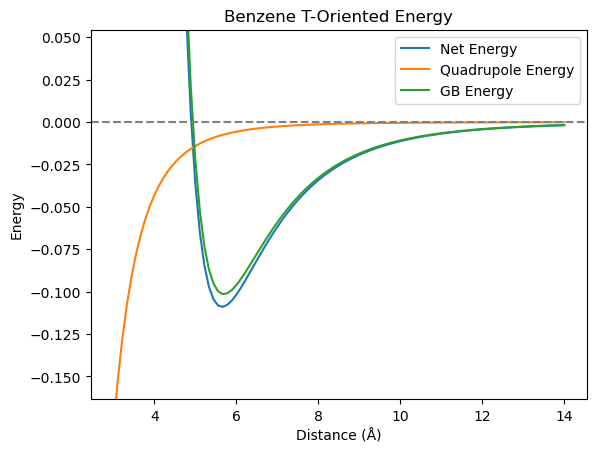

In [52]:
u2 = np.array([0, 1, 0])

gb_t_energies = []
qq_t_energies = []
t_energies = []

for d in distances:
    r = np.array([0, 0, d])
    gb_e = gb(u1, u2, r, popt[0], popt[1], popt[2], popt[3], popt[4], popt[5])
    qq_e = quadrupole(u1, u2, r, popt[6])
    gb_t_energies.append(gb_e)
    qq_t_energies.append(qq_e)
    t_energies.append(gb_e + qq_e)

# plot T energy
plt.plot(distances, t_energies, label='Net Energy')
plt.plot(distances, qq_t_energies, label='Quadrupole Energy')
plt.plot(distances, gb_t_energies, label='GB Energy')
plt.axhline(0, color='gray', linestyle='--')
plt.ylim(min(t_energies)*1.5, abs(min(t_energies))*0.5)
plt.xlabel('Distance (Å)')
plt.ylabel('Energy')
plt.title(f'Benzene T-Oriented Energy')
plt.legend()
plt.show()

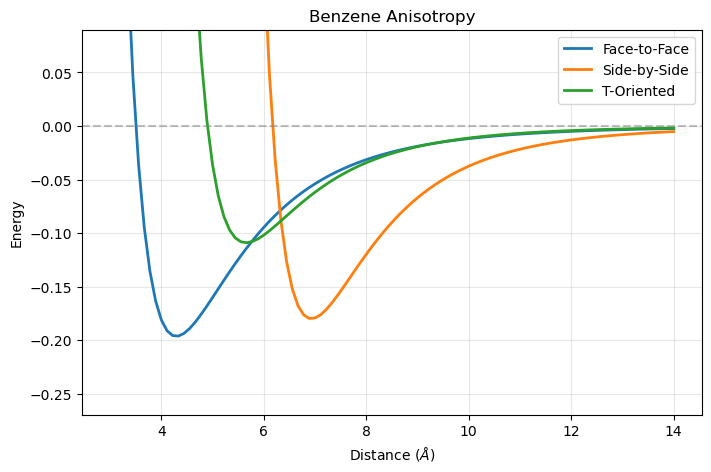

In [53]:
plt.figure(figsize=(8, 5))
plt.plot(distances, face_energies, label='Face-to-Face', linewidth=2)
plt.plot(distances, edge_energies, label='Side-by-Side', linewidth=2)
plt.plot(distances, t_energies, label='T-Oriented', linewidth=2)

plt.axhline(0, color='gray', linestyle='--', alpha=0.5)
plt.ylim(min(edge_energies)*1.5, abs(min(edge_energies))*0.5)
plt.xlabel(r'Distance ($\AA$)')
plt.ylabel('Energy')
plt.title(f'Benzene Anisotropy')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [96]:
n_sigma0 = popt[0]
n_kappa = popt[2]

#                eps0, kappa_prime, mu, nu, Q
n_p0 =           [0.0800, popt[3], -1, popt[5], popt[6]]
n_lower_bounds = [0.0200, 0.001, -10.0, -10.0, -10]
n_upper_bounds = [0.1500, 5.000, 5.000, 10.00, -2]
n_bounds = (n_lower_bounds, n_upper_bounds)

def n_gb_wrapper(matrix, eps0, kappa_prime, mu, nu, Q):
    return get_molecular_energy(matrix, n_sigma0, eps0, n_kappa, kappa_prime, mu, nu, Q)

In [97]:
results2 = curve_fit(
    n_gb_wrapper,
    new_X,
    Y,
    p0=n_p0,
    bounds=n_bounds,
    maxfev=40_000,
    loss="soft_l1",
    f_scale=0.01
)

print(results2)

(array([ 0.13559712,  0.75767416, -9.99999999,  1.84005347, -3.8546178 ]), array([[ 1.62021715e-05,  5.29273251e-05, -4.08848534e-01,
        -6.41971818e-04, -1.72798871e-04],
       [ 5.29273251e-05,  7.03622967e-04, -2.04588883e+00,
        -1.25752193e-03, -1.98601853e-03],
       [-4.08848534e-01, -2.04588883e+00,  5.43103161e+04,
         2.61114575e+01,  8.57918735e+00],
       [-6.41971818e-04, -1.25752193e-03,  2.61114575e+01,
         3.03057364e-02,  5.53152873e-03],
       [-1.72798871e-04, -1.98601853e-03,  8.57918735e+00,
         5.53152873e-03,  2.57475448e-02]]))
